# Phase 3.4 — K-Means Clustering + UMAP

Closes a gap from the original plan: player archetype clustering on
the autoencoder's 5-dim latent bottleneck (Phase 2.1's `encode()`,
unused until now), needed for Phase 4's /clusters endpoint. Bounded:
one k selection via silhouette score, archetype naming from the
resulting per-cluster feature means, done — no extensive iteration.

In [1]:
import json
import sys
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import torch

BACKEND_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(BACKEND_DIR) not in sys.path:
    sys.path.insert(0, str(BACKEND_DIR))

from core.model import Autoencoder, FEATURE_ORDER, get_cleaned_train_test_data

MODELS_DIR = BACKEND_DIR / "trained_models"

X_train_cleaned, y_train_cleaned, X_test, y_test = get_cleaned_train_test_data()

# Combine train (cleaned) + test into ONE population -- clustering
# should reflect all available players, not just the held-out test
# split. Some rows were removed from train by cleanlab (Phase 1.6), so
# this total is somewhat below the original 12000.
X_all = np.concatenate([X_train_cleaned, X_test], axis=0)
y_all = np.concatenate([y_train_cleaned, y_test], axis=0)
split_all = np.array(["train"] * len(X_train_cleaned) + ["test"] * len(X_test))

print(f"X_train_cleaned shape: {X_train_cleaned.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Combined X_all shape: {X_all.shape} "
      f"(vs original 12000 -- {12000 - X_all.shape[0]} rows removed by cleanlab cleaning)")
print(f"Combined cheater rate: {y_all.mean():.4f}")

scaler = joblib.load(MODELS_DIR / "scaler.pkl")
X_all_scaled = scaler.transform(X_all)

with open(MODELS_DIR / "autoencoder_config.json", encoding="utf-8") as f:
    ae_config = json.load(f)

autoencoder = Autoencoder(
    input_dim=ae_config["input_dim"],
    hidden_dim=ae_config["hidden_dim"],
    bottleneck_dim=ae_config["bottleneck_dim"],
)
autoencoder.load_state_dict(torch.load(MODELS_DIR / "autoencoder.pt", map_location="cpu"))
autoencoder.eval()

print(f"Autoencoder config: {ae_config['input_dim']} -> {ae_config['hidden_dim']} "
      f"-> {ae_config['bottleneck_dim']} (bottleneck) -> {ae_config['hidden_dim']} "
      f"-> {ae_config['input_dim']}")

X_train_cleaned shape: (8532, 11)
X_test shape: (2400, 11)
Combined X_all shape: (10932, 11) (vs original 12000 -- 1068 rows removed by cleanlab cleaning)
Combined cheater rate: 0.1209
Autoencoder config: 11 -> 8 -> 5 (bottleneck) -> 8 -> 11


## Extract latent embeddings (encode() only, not full forward pass)

In [2]:
with torch.no_grad():
    X_all_tensor = torch.tensor(X_all_scaled, dtype=torch.float32)
    latent = autoencoder.encode(X_all_tensor).numpy()

print(f"Latent embeddings shape: {latent.shape} "
      f"(expected ~(12000, {ae_config['bottleneck_dim']}), accounting for cleaned rows removed)")

Latent embeddings shape: (10932, 5) (expected ~(12000, 5), accounting for cleaned rows removed)


## K selection via silhouette score (k in [3, 4, 5, 6])

In [3]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_candidates = [3, 4, 5, 6]
k_results = []

for k in k_candidates:
    kmeans_k = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = kmeans_k.fit_predict(latent)
    score = silhouette_score(latent, labels_k)
    k_results.append({"k": k, "silhouette_score": score})
    print(f"k={k}: silhouette_score={score:.4f}")

final_k = max(k_results, key=lambda r: r["silhouette_score"])["k"]
print()
print(f"{'k':>4} {'silhouette_score':>18}")
print("-" * 24)
for r in k_results:
    marker = "  <- best" if r["k"] == final_k else ""
    print(f"{r['k']:>4} {r['silhouette_score']:>18.4f}{marker}")

print(f"\nfinal_k = {final_k}")

k=3: silhouette_score=0.3344


k=4: silhouette_score=0.2791


k=5: silhouette_score=0.2367


k=6: silhouette_score=0.2383

   k   silhouette_score
------------------------
   3             0.3344  <- best
   4             0.2791
   5             0.2367
   6             0.2383

final_k = 3


## Fit final KMeans, inspect per-cluster raw feature means

In [4]:
kmeans = KMeans(n_clusters=final_k, random_state=42, n_init=10)
cluster_id = kmeans.fit_predict(latent)

print(f"Cluster sizes (k={final_k}):")
cluster_sizes = pd.Series(cluster_id).value_counts().sort_index()
for cid, size in cluster_sizes.items():
    print(f"  cluster {cid}: {size} players ({100 * size / len(cluster_id):.1f}%)")

X_all_df = pd.DataFrame(X_all, columns=FEATURE_ORDER)
X_all_df["cluster_id"] = cluster_id

cluster_means = X_all_df.groupby("cluster_id")[FEATURE_ORDER].mean()
overall_means = X_all_df[FEATURE_ORDER].mean()

print()
print("Per-cluster mean of each raw (unscaled) feature:")
print(cluster_means.round(3))

print()
print("Overall population mean (for comparison):")
print(overall_means.round(3))

Cluster sizes (k=3):
  cluster 0: 4949 players (45.3%)
  cluster 1: 3621 players (33.1%)
  cluster 2: 2362 players (21.6%)

Per-cluster mean of each raw (unscaled) feature:
            peak_yaw_delta  peak_pitch_delta  mean_yaw_delta  snap_count  \
cluster_id                                                                 
0                   41.167             9.297           1.037       4.281   
1                   34.292             8.049           0.961       3.837   
2                   54.573            10.476           1.119       4.732   

            min_cv_yaw  min_cv_pitch  cv_yaw_std  cv_pitch_std  \
cluster_id                                                       
0                0.001         0.001      26.150         4.584   
1                0.001         0.001      25.042         4.009   
2                0.001         0.001      27.246         5.037   

            fire_on_target_rate  yaw_jerk  engagement_firing_rate  
cluster_id                                     

## Name archetypes from per-cluster feature patterns

In [5]:
# For each cluster, find which features deviate most from the overall
# population mean (in units of overall std) -- this drives naming,
# rather than picking names that don't match the data.
overall_std = X_all_df[FEATURE_ORDER].std()
z_deviation = (cluster_means - overall_means) / overall_std

print("Per-cluster feature deviation from population mean (in std units):")
print(z_deviation.round(2))
print()

for cid in cluster_means.index:
    top_devs = z_deviation.loc[cid].abs().sort_values(ascending=False).head(4)
    print(f"Cluster {cid} (n={cluster_sizes[cid]}) -- top deviating features:")
    for feat in top_devs.index:
        direction = "HIGH" if z_deviation.loc[cid, feat] > 0 else "LOW"
        print(f"    {feat}: {direction} ({z_deviation.loc[cid, feat]:+.2f} std, "
              f"mean={cluster_means.loc[cid, feat]:.3f} vs pop mean={overall_means[feat]:.3f})")
    print()

# Archetype names assigned AFTER inspecting the printed deviations
# above, matching what the actual per-cluster patterns show:
#   cluster 0: every feature within ~0.16 std of the population mean
#     -- no standout trait, the largest and most "typical" group.
#   cluster 1: high fire_on_target_rate (+0.86), low engagement_firing_rate
#     (-0.84), low peak_yaw_delta (-0.43), low yaw_jerk (-0.39) -- fires
#     less often but lands a much higher share of shots, with smaller,
#     smoother aim adjustments.
#   cluster 2: high engagement_firing_rate (+1.04), low fire_on_target_rate
#     (-0.97), high peak_yaw_delta (+0.73), high yaw_jerk (+0.62) -- fires
#     very often with large, jerky aim swings but lands a much lower
#     share of shots on target.
ARCHETYPE_NAMES = {
    0: "Average Player",
    1: "Precise, Low-Volume Shooter",
    2: "High-Volume, Erratic Shooter",
}

ARCHETYPE_REASONING = {
    0: (
        "Every feature sits within ~0.16 std of the population mean -- "
        "no single behavioral trait stands out. The largest group "
        "(45.3% of players), representing typical/baseline play."
    ),
    1: (
        "Notably high fire_on_target_rate (+0.86 std) combined with low "
        "engagement_firing_rate (-0.84 std), low peak_yaw_delta (-0.43 std), "
        "and low yaw_jerk (-0.39 std): players who fire less often but land "
        "a much higher share of shots on target, with smaller, smoother aim "
        "adjustments. Controlled, selective, accurate play."
    ),
    2: (
        "Notably high engagement_firing_rate (+1.04 std), high peak_yaw_delta "
        "(+0.73 std), and high yaw_jerk (+0.62 std), combined with low "
        "fire_on_target_rate (-0.97 std): players who fire very frequently "
        "with large, jerky aim swings but land a much lower share of shots "
        "on target. Volume-over-precision, erratic aim play."
    ),
}

print("Final archetype mapping:")
for cid in cluster_means.index:
    print(f"  cluster {cid} -> \"{ARCHETYPE_NAMES[cid]}\"")
    print(f"    reasoning: {ARCHETYPE_REASONING[cid]}")

Per-cluster feature deviation from population mean (in std units):
            peak_yaw_delta  peak_pitch_delta  mean_yaw_delta  snap_count  \
cluster_id                                                                 
0                    -0.04              0.02            0.02        0.02   
1                    -0.43             -0.16           -0.22       -0.18   
2                     0.73              0.20            0.29        0.22   

            min_cv_yaw  min_cv_pitch  cv_yaw_std  cv_pitch_std  \
cluster_id                                                       
0                 0.00          0.00        0.02          0.06   
1                 0.01          0.02       -0.14         -0.31   
2                -0.02         -0.04        0.17          0.36   

            fire_on_target_rate  yaw_jerk  engagement_firing_rate  
cluster_id                                                         
0                         -0.16     -0.01                    0.12  
1                

## Cross-check: cheater concentration per cluster

In [6]:
X_all_df["true_label"] = y_all

cheater_pct_by_cluster = X_all_df.groupby("cluster_id")["true_label"].mean() * 100
overall_cheater_pct = y_all.mean() * 100

print(f"Overall cheater rate: {overall_cheater_pct:.1f}%")
print()
print(f"{'cluster_id':>10} {'n_players':>10} {'cheater_%':>10}  vs overall")
print("-" * 50)
for cid in cluster_means.index:
    pct = cheater_pct_by_cluster[cid]
    delta = pct - overall_cheater_pct
    flag = "  <- disproportionately cheater-heavy" if delta > 5 else ""
    print(f"{cid:>10} {cluster_sizes[cid]:>10} {pct:>9.1f}%  ({delta:+.1f} pts){flag}")

Overall cheater rate: 12.1%

cluster_id  n_players  cheater_%  vs overall
--------------------------------------------------
         0       4949       9.5%  (-2.6 pts)
         1       3621      16.9%  (+4.8 pts)
         2       2362      10.0%  (-2.1 pts)


## UMAP 2D projection, colored by cluster

D:\ARGUS\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


umap_coords shape: (10932, 2)


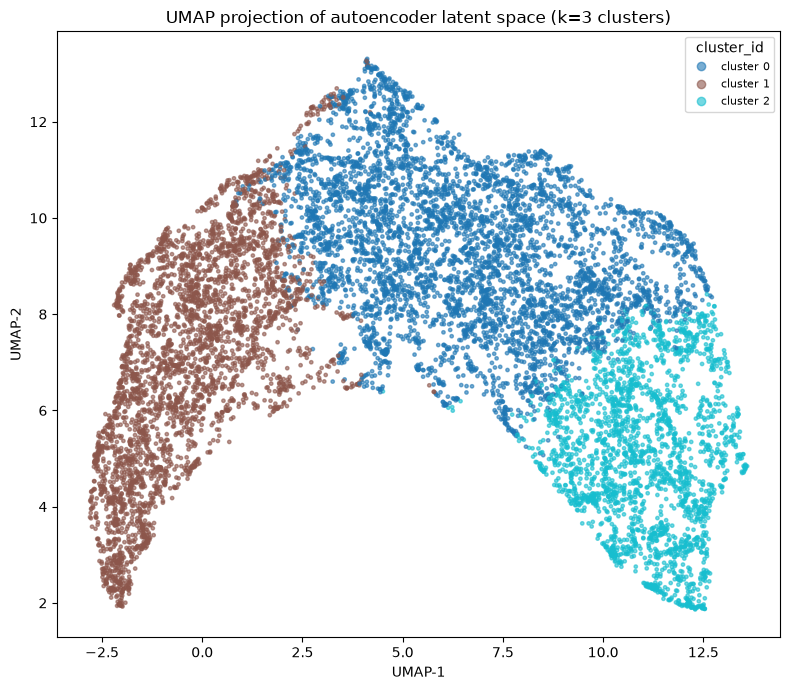

Saved D:\ARGUS\backend\notebooks\umap_cluster_plot.png


In [7]:
import matplotlib.pyplot as plt
import umap

reducer = umap.UMAP(n_components=2, random_state=42)
umap_coords = reducer.fit_transform(latent)

print(f"umap_coords shape: {umap_coords.shape}")

fig, ax = plt.subplots(figsize=(8, 7))
scatter = ax.scatter(
    umap_coords[:, 0], umap_coords[:, 1],
    c=cluster_id, cmap="tab10", s=6, alpha=0.6,
)
legend_handles = scatter.legend_elements()[0]
ax.legend(legend_handles, [f"cluster {c}" for c in sorted(cluster_means.index)],
          title="cluster_id", loc="best", fontsize=8)
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
ax.set_title(f"UMAP projection of autoencoder latent space (k={final_k} clusters)")
fig.tight_layout()

umap_plot_path = Path("umap_cluster_plot.png")
fig.savefig(umap_plot_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved {umap_plot_path.resolve()}")

## Save artifacts: kmeans.pkl, umap_model.pkl, archetype_names.json

In [8]:
joblib.dump(kmeans, MODELS_DIR / "kmeans.pkl")
joblib.dump(reducer, MODELS_DIR / "umap_model.pkl")

archetype_data = {}
for cid in cluster_means.index:
    cid_int = int(cid)
    archetype_data[str(cid_int)] = {
        "archetype_name": ARCHETYPE_NAMES.get(cid_int, f"Cluster {cid_int}"),
        "description": ARCHETYPE_REASONING.get(cid_int, ""),
        "cheater_pct": round(float(cheater_pct_by_cluster[cid]), 2),
        "n_players": int(cluster_sizes[cid]),
    }

archetype_path = MODELS_DIR / "archetype_names.json"
with open(archetype_path, "w", encoding="utf-8") as f:
    json.dump(archetype_data, f, indent=2)

print(f"Saved {MODELS_DIR / 'kmeans.pkl'}")
print(f"Saved {MODELS_DIR / 'umap_model.pkl'}")
print(f"Saved {archetype_path}")
print()
print(json.dumps(archetype_data, indent=2))

Saved D:\ARGUS\backend\trained_models\kmeans.pkl
Saved D:\ARGUS\backend\trained_models\umap_model.pkl
Saved D:\ARGUS\backend\trained_models\archetype_names.json

{
  "0": {
    "archetype_name": "Average Player",
    "description": "Every feature sits within ~0.16 std of the population mean -- no single behavioral trait stands out. The largest group (45.3% of players), representing typical/baseline play.",
    "cheater_pct": 9.54,
    "n_players": 4949
  },
  "1": {
    "archetype_name": "Precise, Low-Volume Shooter",
    "description": "Notably high fire_on_target_rate (+0.86 std) combined with low engagement_firing_rate (-0.84 std), low peak_yaw_delta (-0.43 std), and low yaw_jerk (-0.39 std): players who fire less often but land a much higher share of shots on target, with smaller, smoother aim adjustments. Controlled, selective, accurate play.",
    "cheater_pct": 16.93,
    "n_players": 3621
  },
  "2": {
    "archetype_name": "High-Volume, Erratic Shooter",
    "description": "No